In [1]:
import pickle
import msprime
import numpy as np  # Importing NumPy for numerical operations
import os  # Importing os for operating system functionalities
import argparse  # Importing argparse for command-line argument parsing
import pandas as pd  # Importing pandas for DataFrame manipulation
import zipfile  # Importing zipfile for creating zip archives
import gzip
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import tskit as ts    
import math


In [ ]:
demography_data = {
    'years_ago': [
        20.90991, 27.04340, 34.97601, 45.23550, 58.50439,
        75.66543, 97.86030, 126.56557, 163.69094, 211.70625,
        273.80586, 354.12109, 457.99511, 592.33841, 766.08851,
        990.80457, 1281.43640, 1657.31899, 2143.45890, 2772.19779,
        3585.36410, 4637.05576, 5997.23919, 7756.40403, 10031.58311,
        12974.13845, 16779.83093, 21701.84380, 28067.62632, 36300.67815,
        46948.72375, 60720.15108, 78531.13893, 101566.60798, 131359.05066,
        169890.48403, 219724.30843, 284175.84417, 367532.89150
    ],
    'Ne_log10': [
        3.886466, 4.433363, 4.433363, 4.704220, 4.704220,
        4.701291, 4.701291, 4.696954, 4.696954, 4.691536,
        4.691536, 4.687589, 4.687589, 4.430142, 4.430142,
        4.060712, 4.060712, 3.114804, 3.114804, 3.860018,
        3.860018, 4.953656, 4.953656, 5.028866, 5.028866,
        6.221847, 6.221847, 6.621246, 6.621246, 6.746056,
        6.746056, 6.872533, 6.872533, 6.957109, 6.957109,
        6.885372, 6.885372, 6.300497, 6.300497
    ]
}

# Convert to DataFrame for easier manipulation
demography_df = pd.DataFrame(demography_data)

# User-defined parameters
num_time_points = 39  # Number of time points for demographic changes

# Function to generate population times
def get_population_time(demography_fromdata):
    """Generate population times."""
    divided_years = demography_fromdata['years_ago'] / 0.16  # Divide years_ago by generation time
    divided_years=divided_years.sort_values()
    return  divided_years # Select evenly spaced time points in generations

def sample_population_size(num_time_points, demography_fromdata):
    """Sample population sizes based on demographic data."""
    pop_sizes = np.zeros(num_time_points)
    
    # Ensure demography_df has enough rows
    total_rows = len(demography_fromdata)
    if total_rows == 0:
        raise ValueError("The demography DataFrame is empty.")
    
    # Adjust the loop to prevent out-of-bounds indexing
    for i in range(num_time_points):
        if i >= total_rows:
            raise IndexError(f"Index {i} is out of bounds for demography DataFrame with {total_rows} rows.")
        
        log10_Ne = demography_fromdata['Ne_log10'].iloc[i]
        Ne = 10 ** log10_Ne
        pop_sizes[i] = Ne  #transform and store population sizes according to total time points
    

Constant population size

In [5]:
import msprime
import os

def kingman_constant(Ne=10**4, L=1_000_000, demo="const", r=5e-8, m=1e-7, num_replicates=1, sample_size=10, output_dir="./"):
    """
    Simulate tree sequences using the Kingman Coalescent model with a constant demography
    and save the results as VCF and tree sequence (ts) files for each replicate.
    
    Parameters:
    - Ne (int): Effective population size (default: 10^4).
    - L (int): Sequence length (default: 1,000,000).
    - demo (str): Demography name for file labeling (default: "const").
    - r (float): Recombination rate (default: 5e-8).
    - m (float): Mutation rate (default: 1e-7).
    - num_replicates (int): Number of replicates to simulate (default: 1).
    - sample_size (int): Sample size for the simulation (default: 10).
    - output_dir (str): Directory to save VCF and TS files (default: current directory).
    
    Returns:
    - tree_sequence: The last simulated tree sequence.
    - demography: The demography model used for the simulation.
    """
    # Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)
    
    # Set alpha for Kingman Coalescent
    alpha = 2.0  # Kingman Coalescent corresponds to alpha = 2.0
    
    # Define the demography model
    demography = msprime.Demography()
    demography.add_population(initial_size=Ne)
    
    # Initialize lists to hold filenames
    vcf_filenames = []
    ts_filenames = []
    
    # Loop over the number of replicates
    for i in range(num_replicates):
        # Set a unique random seed for reproducibility
        rs = int((alpha + 1)**2 + i)
        
        # Simulate the ancestry using the Kingman Coalescent model
        tree_sequence = msprime.sim_ancestry(
            samples=sample_size,
            recombination_rate=r,
            sequence_length=L,
            demography=demography,
            ploidy=1,
            random_seed=rs
        )
        
        # Simulate mutations on the tree sequence
        tree_sequence = msprime.sim_mutations(tree_sequence, rate=m, random_seed=rs)
        
        # Define filenames for VCF and tree sequence (ts) outputs
        vcf_filename = os.path.join(
            output_dir,
            f"Kingman_{demo}_rep{i}_m{m:.1e}_r{r:.1e}_rs{rs}.vcf"
        )
        ts_filename = os.path.join(
            output_dir,
            f"Kingman_{demo}_rep{i}_m{m:.1e}_r{r:.1e}_rs{rs}.ts"
        )
        
        # Save the tree sequence as VCF
        with open(vcf_filename, 'w') as vcffh:
            tree_sequence.write_vcf(
                vcffh,
                position_transform='legacy',
                individual_names=[f"spl{str(s)}" for s in range(sample_size)]
            )
        
        # Save the tree sequence to a file
        tree_sequence.dump(ts_filename)

        # Store filenames
        vcf_filenames.append(vcf_filename)
        ts_filenames.append(ts_filename)
    
    print(f"Simulation complete. Files saved to {output_dir}")
    return tree_sequence, demography



In [15]:
# Simulate with custom parameters
tree_sequence, demography = kingman_constant(
    Ne=1000000,
    L=1000000,
    demo="const",
    r=1.29e-08,
    m=1.29e-08,
    num_replicates=1,
    sample_size=50,
    output_dir="/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/SINGER_in_out/Consant_pop_size/kingman1mb"
)

Simulation complete. Files saved to /data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/SINGER_in_out/Consant_pop_size/kingman1mb


In [ ]:


L=1_000_000
r=5e-8
num_replicates=100
m=1e-07
Ne=10000

alpha = 2.0  # Kingman Coalescent corresponds to alpha = 2.0
demography = msprime.Demography()
demography.add_population(initial_size=Ne)

tree_sequence=[]

for i in range(10):
        
    # Set a unique random seed for each replicate
    rs = (alpha + 1)**2 + i
        
    # Simulate the ancestry using the Kingman Coalescent model
    tree_sequence = msprime.sim_ancestry(
            samples=10,
            recombination_rate=r,
            sequence_length=L,
            demography=demography,
            ploidy=1,
            random_seed=rs)

# Simulate mutations on the tree sequence
tree_sequence = msprime.sim_mutations(tree_sequence, rate=m, random_seed=rs)

In [1]:
def compute_all_coalescence_times(trees):
    kb = [0]  # Starting genomic position
    mrca_time = []
    for tree in trees.trees():
        kb.append(tree.interval.right/1000)  # convert to kb
        mrca = trees.node(tree.root)  # For msprime tree sequences, the root node is the MRCA
        mrca_time.append(mrca.time)
        
    plt.stairs(mrca_time, kb, baseline=None)
    plt.xlabel("Genome position (kb)")
    plt.ylabel("Time of root (or MRCA) in generations")
    plt.yscale("log")
    plt.show()

    return mrca_time

In [2]:
mrca_time=compute_all_coalescence_times(tree_sequence)

NameError: name 'tree_sequence' is not defined

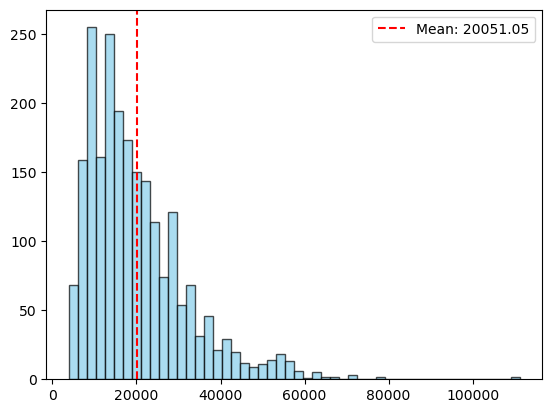

In [18]:

# Assuming mrca_time is a list or array of values
mean_value = np.mean(mrca_time)

# Plot the histogram
plt.hist(mrca_time, bins=50, alpha=0.7, color='skyblue', edgecolor='black')

# Plot the mean as a vertical line
plt.axvline(mean_value, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean_value:.2f}')

# Add a legend
plt.legend()

# Show the plot
plt.show()


In [1]:


def beta_constant(alpha, Ne=10**4, r=5e-8, L=10**4, num_replicates=1, sample_size=10, m=1e-8, rs=None, outdir="./output"):
    
    # Validate the alpha parameter
    if alpha <= 1.0:
        raise ValueError("The alpha parameter for the Beta coalescent must be > 1.0.")
    
    # Create the output directory if it doesn't exist
    os.makedirs(outdir, exist_ok=True)
    
    # Set up the demographic model
    demography = msprime.Demography()
    demography.add_population(initial_size=Ne)
    
    # Simulate tree sequences under the Beta coalescent model
    tree_sequences = msprime.sim_ancestry(
        samples=sample_size,
        recombination_rate=r,
        sequence_length=L,
        demography=demography,
        ploidy=1,  # Assuming diploid organisms
        model=msprime.BetaCoalescent(alpha=alpha),
        num_replicates=num_replicates,
        random_seed=rs
    )
    
    # Simulate mutations and save results
    mutated_tree_sequences = []
    for i, tree_sequence in enumerate(tree_sequences):
        # Simulate mutations
        mutated_ts = msprime.sim_mutations(tree_sequence, rate=m, random_seed=rs)
        mutated_tree_sequences.append(mutated_ts)
        
        # Save the tree sequence to a file
        ts_filename = os.path.join(outdir, f"Beta{i}_alpha{alpha}_m{m}_r{r}.ts")
        mutated_ts.dump(ts_filename)
        
        # Optionally, save the VCF file
        vcf_filename = os.path.join(outdir, f"Beta{i}_alpha{alpha}_m{m}_r{r}.vcf")
        with open(vcf_filename, "w") as vcf_file:
            mutated_ts.write_vcf(vcf_file)
    
    return mutated_tree_sequences, demography




In [14]:
mutated_trees, demography = beta_constant(
    alpha=1.9, 
    Ne=1000000, 
    r=1.29e-8, 
    L=1_000_000, 
    num_replicates=1, 
    sample_size=50, 
    m=1e-8, 
    rs=42, 
    outdir="/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/SINGER_in_out/Consant_pop_size/1mb"
)


In [2]:
def beta_constant(alpha, demo="Const" ,Ne=10**4, L, r, m, num_replicates=1, sample_size=25):
    """
    Simulate tree sequences using the Beta Coalescent model with a constant alpha and
    save the results as VCF and tree sequence (ts) files for each replicate.
    
    Parameters:
    - alpha (float): Beta coalescent alpha parameter.
    - Ne (int): Effective population size (default: 10^4).
    - L (int): Sequence length (default: 1,000,000).
    - r (float): Recombination rate (default: 5e-8).
    - num_replicates (int): Number of replicates to simulate (default: 5).
    - sample_size (int): Sample size for the simulation (default: 10).
    - m (float): Mutation rate (default: 1e-7).
    
    Returns:
    - tree_sequence: The last simulated tree sequence.
    - demography: The demography model used for the simulation.
    """
    
    alpha = 1.5  # Set alpha for the Beta coalescent
    demography = msprime.Demography()
    demography.add_population(initial_size=Ne)

    # Initialize lists to hold filenames
    vcf_filenames = []
    ts_filenames = []
    
    for i in range(num_replicates):
        # Set a unique random seed for each replicate
        rs = (alpha + 1)**2 + i
        
        # Simulate the ancestry using the Beta Coalescent model
        tree_sequence = msprime.sim_ancestry(
            samples=sample_size,
            recombination_rate=r,
            sequence_length=L,
            demography=demography,
            ploidy=2,
            model=msprime.BetaCoalescent(alpha=alpha),
            random_seed=rs
        )
        
        # Simulate mutations on the tree sequence
        tree_sequence = msprime.sim_mutations(tree_sequence, rate=m, random_seed=rs)
        
        # Define filenames for VCF and tree sequence (ts) outputs
        vcf_filename = (
            f'/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/'
            f'msprime_sims/SINGER_in_out/recom_mutation_1e2/Constant_popsize/Inputs/'
            f'BetaCoal_{demo}_rep{i}_m{m}_r{r}_rs{rs}.vcf'
        )
        ts_filename = (
            f'/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/'
            f'msprime_sims/SINGER_in_out/recom_mutation_1e2/Constant_popsize/Inputs/'
            f'BetaCoal_{demo}_rep{i}_m{m}_r{r}_rs{rs}.ts'
        )
        
        # Save the tree sequence as VCF
        with open(vcf_filename, 'w') as vcffh:
            tree_sequence.write_vcf(
                vcffh,
                position_transform='legacy',
                individual_names=[f'spl{str(s)}' for s in range(sample_size)]
            )
        
        # Save the tree sequence to a file
        tree_sequence.dump(ts_filename)

        # Store filenames
        vcf_filenames.append(vcf_filename)
        ts_filenames.append(ts_filename)

    return tree_sequence, demography  # Return the last tree sequence and the demography model



SyntaxError: non-default argument follows default argument (1800259569.py, line 1)

In [ ]:
tree, demo=beta_constant(alpha=1.9)

Random demography

In [ ]:
def sample_population_size(n_min:int=10, n_max:int=100_000, num_time_windows=21) -> list[float]:

    """Creates random demography. Function taken from: 
    https://gitlab.inria.fr/ml_genetics/public/dlpopsize_paper
    
    :param int n_min: Lower-bound of demography.
    :param int n_max: Upper-bound of demography.
    :param int num_time_windows: Number of population sizes in demography.
    :return list: 
    """

    n_min_log10 = np.log10(n_min)
    n_max_log10 = np.log10(n_max)
    population_size = [10 ** np.random.uniform(low=n_min_log10, high=n_max_log10)]
    for j in range(num_time_windows - 1):
        population_size.append(10 ** n_min_log10 - 1)
        while population_size[-1] > 10 ** n_max_log10 or population_size[-1]  < 10 ** n_min_log10:
            population_size[-1] = population_size[-2] * 10 ** np.random.uniform(-1, 1)

    return population_size

def get_random_time_and_demography():
    from scipy.interpolate import interp1d
    upper_out_of_bound = lower_out_of_bound = True
    while upper_out_of_bound or lower_out_of_bound:
        steps = 18
        x = np.log(get_population_time(time_rate=0.1, num_time_windows=steps, tmax=10_000_000).tolist())
        y = np.log(sample_population_size(10_000, 10_000_000, steps))
        xnew = np.linspace(x[0], x[-1], num=10000, endpoint=True)
        f_cubic = interp1d(x, y, kind='cubic')
        ynew = f_cubic(xnew)
        upper_out_of_bound = np.sum(np.exp(ynew) > 10_000_000) > 0
        lower_out_of_bound = np.sum(np.exp(ynew) < 10_000) > 0
    x_sample = xnew[np.linspace(10, 9999, 60).astype(int)]
    y_sample = ynew[np.linspace(10, 9999, 60).astype(int)]
    demography = np.exp(y_sample)
    population_time = np.exp(x_sample)
    return population_time, demography

population_time, demography = get_random_time_and_demography()
#sns.lineplot(x=population_time, y=demography)
#plt.yscale('log')
#plt.xscale('log')
#plt.ylim(1000, 100_000_000)
#plt.xlim(10,10_000_000)

SawTooth

In [12]:
import msprime
import numpy as np
import matplotlib.pyplot as plt

def get_population_time(time_rate: float = 0.06, tmax: int = 130_000, num_time_windows: int = 21) -> np.array:
    """Creates population time points; used as time points to change
    population size changes for simulation.
    
    :return numpy.ndarray: time points of length num_time_windows
    """
    population_time = np.repeat([(np.exp(np.log(1 + time_rate * tmax) * i /
                              (num_time_windows - 1)) - 1) / time_rate for i in
                              range(num_time_windows)], 1, axis=0)
    
    population_time[0] = 1
    return population_time, num_time_windows



In [47]:

def simulate_sawtooth(Ne=10**4, L=1_000_000, sample_size=10, r=R, m=M, ploidy=1, beta_coalescent=False, alpha=1.5, save_coal_times=False,num_replicates=10):
    """Simulates a sawtooth demography using dynamic time points, and tracks population sizes."""
    
    # Determine model type for naming files
    model_type = "Beta" if beta_coalescent else "Kingman"
    
    # Prefixed variables for saving data
    pref = f"{model_type}_r{r}_m{m}_"
    alpha_param = alpha  # Use this alpha for Beta coalescent if specified
    
    # Initialize demography and set initial population size
    demography = msprime.Demography()
    demography.add_population(initial_size=(Ne))

    time_points = [
        0,
        20, 30, 200, 300, 2000,
        3000, 20000, 30000, 200000,
        300000, 2000000, 3000000, 20000000  # Final reset to Ne
    ]
    
    # Fixed growth rates from the sawtooth model
    growth_rates = [
        6437.7516497364, -378.691273513906, -643.77516497364,
        37.8691273513906, 64.377516497364, -3.78691273513906,
        -6.4377516497364, 0.378691273513906, 0.64377516497364,
        -0.0378691273513906, -0.064377516497364, 0.00378691273513906
    ]
    
    # Initialize population size tracker with the starting population size
    current_pop_size = Ne
    demo = [current_pop_size]  # List to store the population sizes over time

    # Add population size changes at dynamic time points with fixed growth rates
    for i, time_point in enumerate(time_points[1:]):
        if i < len(growth_rates):
            growth_rate = growth_rates[i] / (4 * 10**4)
            # Update the current population size using exponential growth formula
            new_pop_size = current_pop_size * np.exp(growth_rate * (time_point - time_points[i - 1] if i > 0 else 1))
            demo.append(new_pop_size)
            
            # Add to demography: use the updated population size
            demography.add_population_parameters_change(time=time_point, growth_rate=growth_rate, initial_size=new_pop_size)
            
            # Set the current population size for the next step
            current_pop_size = new_pop_size

    # Final reset of population size to the original Ne at the last time point
    demography.add_population_parameters_change(time=time_points[-1], growth_rate=0, initial_size=Ne)
    demo.append(Ne)  # Append the final population size
    
    # Debugger to verify demography
    db = msprime.DemographyDebugger(demography=demography)
    
    # Simulate tree sequences and save them
    tree_sequences = []
    
    for i in range(int(num_replicates)):
        rs=((alpha_param * i + 1)**2)
        # Simulate ancestry and mutations
        if beta_coalescent:
            # Simulate a Beta coalescent model
            tree_sequence = msprime.sim_ancestry(
                samples=sample_size,
                recombination_rate=r, 
                sequence_length=L, 
                demography=demography,
                ploidy=1,
                model=msprime.BetaCoalescent(alpha=alpha),
                random_seed=rs
            )
        else:
            # Default to Kingman's coalescent model
            tree_sequence = msprime.sim_ancestry(
                samples=sample_size, 
                recombination_rate=r, 
                sequence_length=L, 
                demography=demography, 
                ploidy=1, 
                random_seed=rs
            )
        
        # Mutate the tree sequence
        tree_sequence = msprime.sim_mutations(tree_sequence, rate=m,random_seed=rs)
        
        # Save VCF and tree sequence files with the appropriate model name
        output_directory = "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/trial1/Sawtooth_trees_new"
        vcf_filename = os.path.join(output_directory, f'SawToothSim_seed{rs}_{pref}{i}.vcf')
        with open(vcf_filename, 'w') as vcffh:
            tree_sequence.write_vcf(vcffh, position_transform='legacy', individual_names=[f'spl{str(s)}' for s in range(sample_size)])
        
        ts_filename = os.path.join(output_directory, f'SawToothSim_seed{rs}_{pref}{i}.trees')
        tree_sequence.dump(ts_filename)
        
        # Calculate and save coalescence times for each pair of samples if save_coal_times is True
        if save_coal_times:
            for s1 in range(0, sample_size-1):
                for s2 in range(s1 + 1, sample_size):
                    with open(f'SawToothSim_{pref}{i}_samples{s1}-{s2}.tc', 'w') as coaltimefh:
                        for tree in tree_sequence.trees():
                            tree_interval = tree.get_interval()
                            coalescence_time = tree.tmrca(s1, s2)
                            print(tree_interval[0], tree_interval[1], coalescence_time, sep="\t", file=coaltimefh)
        
        tree_sequences.append(tree_sequence)

    # Return tree sequences and demographic details
    return tree_sequences, demography, time_points, demo



In [48]:
# Running the simulation
tree_sequences, demography_trajectory, population_time, demo = simulate_sawtooth(
      Ne=10**4, 
    L=1_000_000, 
    sample_size=10, 
    r=R, 
    m=M,
    ploidy=1, 
    beta_coalescent=False, 
    alpha=1.5,
    save_coal_times=False,
    num_replicates=100

)

tree_sequences, demography, time_points, demo = simulate_sawtooth(
    Ne=10**4, 
    L=1_000_000, 
    sample_size=10, 
    r=R, 
    m=M,
    ploidy=1, 
    beta_coalescent=True, 
    alpha=1.5,
    save_coal_times=False,
    num_replicates=100
)


Custom Demography

In [5]:
# Demographic data
demography_data = {
    'years_ago': [
        20.90991, 27.04340, 34.97601, 45.23550, 58.50439,
        75.66543, 97.86030, 126.56557, 163.69094, 211.70625,
        273.80586, 354.12109, 457.99511, 592.33841, 766.08851,
        990.80457, 1281.43640, 1657.31899, 2143.45890, 2772.19779,
        3585.36410, 4637.05576, 5997.23919, 7756.40403, 10031.58311,
        12974.13845, 16779.83093, 21701.84380, 28067.62632, 36300.67815,
        46948.72375, 60720.15108, 78531.13893, 101566.60798, 131359.05066,
        169890.48403, 219724.30843, 284175.84417, 367532.89150
    ],
    'Ne_log10': [
        3.886466, 4.433363, 4.433363, 4.704220, 4.704220,
        4.701291, 4.701291, 4.696954, 4.696954, 4.691536,
        4.691536, 4.687589, 4.687589, 4.430142, 4.430142,
        4.060712, 4.060712, 3.114804, 3.114804, 3.860018,
        3.860018, 4.953656, 4.953656, 5.028866, 5.028866,
        6.221847, 6.221847, 6.621246, 6.621246, 6.746056,
        6.746056, 6.872533, 6.872533, 6.957109, 6.957109,
        6.885372, 6.885372, 6.300497, 6.300497
    ]
}

# Convert demographic data to DataFrame
demography_df = pd.DataFrame(demography_data)

# Function to generate population time points
def get_population_time():
    """Generate population time points by dividing years_ago by generation time."""
    divided_years = demography_df['years_ago'] / 0.16  # Divide by generation time
    return divided_years.sort_values()

# Function to sample population sizes
def sample_population_size(num_time_points, demography_fromdata):
    """Sample population sizes based on demographic data."""
    pop_sizes = np.zeros(num_time_points)
    
    # Ensure demography_df has enough rows
    total_rows = len(demography_fromdata)
    if total_rows == 0:
        raise ValueError("The demography DataFrame is empty.")
    
    for i in range(num_time_points):
        if i >= total_rows:
            raise IndexError(f"Index {i} is out of bounds for demography DataFrame with {total_rows} rows.")
        
        log10_Ne = demography_fromdata['Ne_log10'].iloc[i]
        Ne = 10 ** log10_Ne
        pop_sizes[i] = np.random.uniform(max(0, Ne - 1000), Ne + 1000)  # Sample within ±1000 around Ne
    
    return pop_sizes

# Simulate using Beta coalescent model
def simulate_beta_coalescent(alpha, demo="Custom_demo", Ne=10**4, L=1_000_000, r=R, m=M, num_replicates=1, sample_size=10, population_time=None, population_size=None):
    """
    Simulate tree sequences using the Beta Coalescent model and save as VCF and tree sequence files.
    """
    demography = msprime.Demography()
    demography.add_population(initial_size=population_size[0])

    vcf_filenames = []
    ts_filenames = []
    
    for time, size in zip(population_time[1:], population_size[1:]):
        demography.add_population_parameters_change(time=time, initial_size=size)
    
    for i in range(num_replicates):
        # Set random seed for each replicate
        rs = (alpha + 1)**2 + i
        
        # Simulate the ancestry with Beta Coalescent
        tree_sequence = msprime.sim_ancestry(
            samples=sample_size,
            recombination_rate=r,
            sequence_length=L,
            demography=demography,
            ploidy=1,
            model=msprime.BetaCoalescent(alpha=alpha),
            random_seed=int(rs)
        )

        # Add mutations to the tree sequence
        tree_sequence = msprime.sim_mutations(tree_sequence, rate=m, random_seed=int(rs))

        # Define filenames for VCF and tree sequence (ts) outputs
        vcf_filename = (
            f'/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/'
            f'msprime_sims/SINGER_in_out/recom_mutation_1e1/Custom_demo/'
            f'BetaCoal_{demo}_rep{i}_m{m}_r{r}_rs{rs}.vcf'
        )
        ts_filename = (
            f'/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/'
            f'msprime_sims/SINGER_in_out/recom_mutation_1e1/Custom_demo/'
            f'BetaCoal_{demo}_rep{i}_m{m}_r{r}_rs{rs}.ts'
        )

        # Write VCF
        with open(vcf_filename, 'w') as vcf_file:
            tree_sequence.write_vcf(vcf_file)

        # Save tree sequence
        tree_sequence.dump(ts_filename)

        vcf_filenames.append(vcf_filename)
        ts_filenames.append(ts_filename)

    return tree_sequence, demography

# Simulate using Kingman coalescent model
def kingman_constant(Ne=10**4, demo="Custom_demo",L=1_000_000, r=R, m=M num_replicates=1, sample_size=10,population_time=None, population_size=None):
    """
    Simulate tree sequences using the Kingman Coalescent model and save as VCF and tree sequence files.
    """
    demography = msprime.Demography()
    demography.add_population(initial_size=population_size[0])

    vcf_filenames = []
    ts_filenames = []

    for time, size in zip(population_time[1:], population_size[1:]):
        demography.add_population_parameters_change(time=time, initial_size=size)
    
    for i in range(num_replicates):
        # Set random seed
        rs = (1.5 + 1)**2 + i  # Set alpha to 1.5 for Kingman

        # Simulate ancestry with Kingman Coalescent
        tree_sequence = msprime.sim_ancestry(
            samples=sample_size,
            recombination_rate=r,
            sequence_length=L,
            demography=demography,
            ploidy=1,
            random_seed=int(rs)
        )

        # Add mutations
        tree_sequence = msprime.sim_mutations(tree_sequence, rate=m, random_seed=int(rs))

        # Save files
        vcf_filename = (
            f'/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/'
            f'msprime_sims/SINGER_in_out/recom_mutation_1e1/Custom_demo/Custom_demo_input/'
            f'Kingman_{demo}_rep{i}_m{m}_r{r}_rs{rs}.vcf'
        )
        ts_filename = (
            f'/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/'
            f'msprime_sims/SINGER_in_out/recom_mutation_1e1/Custom_demo/Custom_demo_input/'
            f'Kingman_{demo}_rep{i}_m{m}_r{r}_rs{rs}.ts'
        )


        # Write VCF
        with open(vcf_filename, 'w') as vcf_file:
            tree_sequence.write_vcf(vcf_file)

        # Save tree sequence
        tree_sequence.dump(ts_filename)

        vcf_filenames.append(vcf_filename)
        ts_filenames.append(ts_filename)

    return tree_sequence, demography

# Generate population time and size from demographic data
num_time_points = len(demography_df)
population_time = get_population_time()
population_size = sample_population_size(num_time_points, demography_df)

# Run Beta coalescent simulation
tree_sequence_beta, demography_beta = simulate_beta_coalescent(alpha=1.5, num_replicates=100, sample_size=10, population_time=population_time, population_size=population_size)

# Run Kingman coalescent simulation
tree_sequence_kingman, demography_kingman = kingman_constant(num_replicates=100, sample_size=10, population_time=population_time, population_size=population_size)


Examine Trees

In [6]:
ts = tskit.load("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/trial1/$/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/parallel_trial/SawToothSim_Beta_r1e-08_m1e-07_1/SawToothSim_Beta_r1e-08_m1e-07_1_1.trees")


In [37]:
ts_sim = tskit.load("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/SINGER_trees/Trees_different_demographies/BetaCoal_Const_rep0_m1e-07_r5e-08_rs6.25.ts")
ts_inf=tskit.load("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/SINGER_trees/Trees_different_demographies/outputs/BetaCoal_Const_rep0_m1e-07_r5e-08_rs6.25/BetaCoal_Const_rep0_m1e-07_r5e-08_rs6.25_singerout_0.trees")

In [38]:
output_file = "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/SINGER_trees/Trees_different_demographies/BetaCoal_Const_rep0_m1e-07_r5e-08_rs6.25.newick"

with open(output_file, "w") as f:
    for tree in ts_sim.trees():  # Replace ts_sim with your actual TreeSequence object
        f.write(tree.newick() + "\n")

ts_sim

Misc scripts


In [ ]:
vcfdir='/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/trial1'
tsdir='/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/trial1'
tcdir='/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/trial1'

# Kingman coalescent model with a sawtooth demographic history
def kingman_sawtooth(Ne=10**4, L=10_000_000, sample_size=10, r=R, m=M, ploidy=1):   
    # Prefix for file naming based on recombination and mutation rates
    pref = "r" + str(r) + "m" + str(m) + "_"
    alpha = 2.0  # Used in the random seed for reproducibility

    # Initialize demographic model with an initial population size Ne
    demography = msprime.Demography()
    demography.add_population(initial_size=Ne)

    # Adding a series of demographic changes over time to simulate sawtooth pattern
    # The growth_rate is calculated relative to the effective population size (Ne)
    demography.add_population_parameters_change(time=20, growth_rate=6437.7516497364/(4*10**4))
    demography.add_population_parameters_change(time=30, growth_rate=-378.691273513906/(4*10**4))
    demography.add_population_parameters_change(time=200, growth_rate=-643.77516497364/(4*10**4))
    demography.add_population_parameters_change(time=300, growth_rate=37.8691273513906/(4*10**4))
    demography.add_population_parameters_change(time=2000, growth_rate=64.377516497364/(4*10**4))
    demography.add_population_parameters_change(time=3000, growth_rate=-3.78691273513906/(4*10**4))
    demography.add_population_parameters_change(time=20000, growth_rate=-6.4377516497364/(4*10**4))
    demography.add_population_parameters_change(time=30000, growth_rate=0.378691273513906/(4*10**4))
    demography.add_population_parameters_change(time=200000, growth_rate=0.64377516497364/(4*10**4))
    demography.add_population_parameters_change(time=300000, growth_rate=-0.0378691273513906/(4*10**4))
    demography.add_population_parameters_change(time=2000000, growth_rate=-0.064377516497364/(4*10**4))
    demography.add_population_parameters_change(time=3000000, growth_rate=0.00378691273513906/(4*10**4))
    demography.add_population_parameters_change(time=20000000, growth_rate=0, initial_size=Ne)

    # Debugger to display demographic model information (optional for debugging)
    db = msprime.DemographyDebugger(demography=demography)

    # Store the resulting tree sequences
    tree_sequences = []
    n = sample_size  # Number of samples in each simulation
    
    # Run 10 independent simulations
    for i in range(10):
        # Simulate the ancestry of the samples with recombination
        tree_sequence = msprime.sim_ancestry(
            samples=sample_size, recombination_rate=r, sequence_length=L, 
            demography=demography, ploidy=1, random_seed=((alpha*i+1)**2)
        )
        
        # Add mutations to the ancestry
        tree_sequence = msprime.mutate(tree_sequence, rate=m)
        
        # Save the VCF file containing the genetic variants
        vcffh = open(vcfdir + 'kingman_sim_' + pref + str(i) + '.vcf', 'w')
        tree_sequence.write_vcf(
            vcffh, position_transform='legacy', 
            individual_names=['spl' + str(s) for s in range(int(n))]
        )
        vcffh.close()
        
        # Save the tree sequence to a file
        tsfile = tsdir + 'sim_' + pref + str(i) + '.trees'
        tree_sequence.dump(tsfile)
        
        # Calculate coalescence times between all pairs of samples
        for s1 in range(0, n - 1):
            for s2 in range(s1 + 1, n):
                coaltimefh = open(tcdir + '/kingman_sim_' + pref + str(i) + '_spls' + str(s1) + '-' + str(s2) + '.tc', 'w')
                for tree in tree_sequence.trees():
                    treeInterval = tree.get_interval()  # The length of the sequence that this tree spans
                    coalescence_time = tree.tmrca(s1, s2)  # Time to most recent common ancestor
                    print(treeInterval[0], treeInterval[1], coalescence_time, sep="\t", file=coaltimefh)
                coaltimefh.close()

        # Append the current tree sequence to the list
        tree_sequences.append(tree_sequence)

    # Retrieve the demographic history for all population time points (optional for analysis)
    demography = db.population_size_trajectory(population_time).flatten()
    
    return list(tree_sequences), demography


# Beta coalescent model with a sawtooth demographic history
def beta_sawtooth(alpha, Ne=10**6, L=10_000_000, sample_size=10, r=1e-8, m=1e-7, ploidy=1):
    # Prefix for file naming based on recombination and mutation rates
    pref = "r" + str(r) + "m" + str(m) + "_"

    # Initialize demographic model with an initial population size Ne
    demography = msprime.Demography()
    demography.add_population(initial_size=Ne)

    # Adding a series of demographic changes over time to simulate sawtooth pattern
    demography.add_population_parameters_change(time=20, growth_rate=6437.7516497364/(4*10**4))
    demography.add_population_parameters_change(time=30, growth_rate=-378.691273513906/(4*10**4))
    demography.add_population_parameters_change(time=200, growth_rate=-643.77516497364/(4*10**4))
    demography.add_population_parameters_change(time=300, growth_rate=37.8691273513906/(4*10**4))
    demography.add_population_parameters_change(time=2000, growth_rate=64.377516497364/(4*10**4))
    demography.add_population_parameters_change(time=3000, growth_rate=-3.78691273513906/(4*10**4))
    demography.add_population_parameters_change(time=20000, growth_rate=-6.4377516497364/(4*10**4))
    demography.add_population_parameters_change(time=30000, growth_rate=0.378691273513906/(4*10**4))
    demography.add_population_parameters_change(time=200000, growth_rate=0.64377516497364/(4*10**4))
    demography.add_population_parameters_change(time=300000, growth_rate=-0.0378691273513906/(4*10**4))
    demography.add_population_parameters_change(time=2000000, growth_rate=-0.064377516497364/(4*10**4))
    demography.add_population_parameters_change(time=3000000, growth_rate=0.00378691273513906/(4*10**4))
    demography.add_population_parameters_change(time=20000000, growth_rate=0, initial_size=Ne)

    # Debugger to display demographic model information (optional for debugging)
    db = msprime.DemographyDebugger(demography=demography)

    # Store the resulting tree sequences
    tree_sequences = []
    n = sample_size  # Number of samples in each simulation
    
    # Run 10 independent simulations with the Beta coalescent model
    for i in range(10):
        # Simulate the ancestry of the samples with recombination using Beta coalescent
        tree_sequence = msprime.sim_ancestry(
            samples=sample_size, recombination_rate=r, sequence_length=L, 
            demography=demography, ploidy=1, random_seed=((alpha*i+1)**2), 
            model=msprime.BetaCoalescent(alpha=alpha)
        )
        
        # Add mutations to the ancestry
        tree_sequence = msprime.mutate(tree_sequence, rate=m)
        
        # Save the VCF file containing the genetic variants
        vcffh = open(vcfdir + 'beta_sim_' + str(alpha) + '_' + pref + str(i) + '.vcf', 'w')
        tree_sequence.write_vcf(
            vcffh, position_transform='legacy', 
            individual_names=['spl' + str(s) for s in range(int(n))]
        )
        vcffh.close()
        
        # Save the tree sequence to a file
        tsfile = tsdir + 'beta_sim_' + str(alpha) + "_" + pref + str(i) + '.trees'
        tree_sequence.dump(tsfile)
        
        # Calculate coalescence times between all pairs of samples
        for s1 in range(0, n - 1):
            for s2 in range(s1 + 1, n):
                coaltimefh = open(tcdir + '/beta_' + str(alpha) + '_sim_' + pref + str(i) + '_spls' + str(s1) + '-' + str(s2) + '.tc', 'w')
                for tree in tree_sequence.trees():
                    treeInterval = tree.get_interval()  # The length of the sequence that this tree spans
                    coalescence_time = tree.tmrca(s1, s2)  # Time to most recent common ancestor
                    print(treeInterval[0], treeInterval[1], coalescence_time, sep="\t", file=coaltimefh)
                coaltimefh.close()

        # Append the current tree sequence to the list
        tree_sequences.append(tree_sequence)

    # Retrieve the demographic history for all population time points (optional for analysis)
    demography = db.population_size_trajectory(population_time).flatten()
    
    return list(tree_sequences), demography


# Run Beta coalescent simulations with different alpha values
tree_sequences_b19, demography = beta_sawtooth(1.9, r=1e-9, m=1e-8, L=10_000_000)
tree_sequences_b17, demography = beta_sawtooth(1.7, r=1e-8, m=1e-7, L=10_000_000)
tree_sequences_b15, demography = beta_sawtooth(1.5, r=1e-8, m=1e-7, L=10_000_000)
tree_sequences_b13, demography = beta_sawtooth(1.3, r=1e-7, m=1e-6, L=10_000_000)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_sawtooth_demography():
    # Define the time points and corresponding growth rates as per the demographic changes
    times = [20, 30, 200, 300, 2000, 3000, 20000, 30000, 200000, 300000, 2000000, 3000000, 20000000]
    growth_rates = [6437.7516497364/(4*10**4), -378.691273513906/(4*10**4), -643.77516497364/(4*10**4), 
                    37.8691273513906/(4*10**4), 64.377516497364/(4*10**4), -3.78691273513906/(4*10**4),
                    -6.4377516497364/(4*10**4), 0.378691273513906/(4*10**4), 0.64377516497364/(4*10**4), 
                    -0.0378691273513906/(4*10**4), -0.064377516497364/(4*10**4), 
                    0.00378691273513906/(4*10**4), 0]

    # Initial population size
    Ne = 10**4
    
    # Population sizes over time
    population_sizes = [Ne]

    # Calculate population sizes based on growth rates
    for i in range(1, len(times)):
        delta_t = times[i] - times[i-1]
        previous_size = population_sizes[-1]
        growth_rate = growth_rates[i-1]
        # Use exponential growth/decline formula: N(t) = N0 * exp(growth_rate * delta_t)
        new_size = previous_size * np.exp(growth_rate * delta_t)
        population_sizes.append(new_size)
    
    # Plot the population size trajectory
    plt.figure(figsize=(10, 6))
    plt.plot(times, population_sizes, marker="o", label="Population Size")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Time (generations)")
    plt.ylabel("Population Size")
    plt.title("Sawtooth Demography over Time")
    plt.grid(True)
    plt.legend()
    plt.show()

# Call the function to plot the demography
plot_sawtooth_demography()


In [8]:
import msprime
import numpy as np

def kingman_sawtooth_with_loop(Ne=10**4, L=10_000_000, sample_size=10, r=1e-8, m=1e-7, ploidy=1):   
    # Prefix for file naming based on recombination and mutation rates
    pref = "r" + str(r) + "m" + str(m) + "_"
    alpha = 2.0  # Used in the random seed for reproducibility

    # Initialize demographic model with an initial population size Ne
    demography = msprime.Demography()
    demography.add_population(initial_size=Ne)

    # Time points and growth rates for the demographic changes
    times = [20, 30, 200, 300, 2000, 3000, 20000, 30000, 200000, 300000, 2000000, 3000000, 20000000]
    growth_rates = [6437.7516497364/(4*10**4), -378.691273513906/(4*10**4), -643.77516497364/(4*10**4), 
                    37.8691273513906/(4*10**4), 64.377516497364/(4*10**4), -3.78691273513906/(4*10**4),
                    -6.4377516497364/(4*10**4), 0.378691273513906/(4*10**4), 0.64377516497364/(4*10**4), 
                    -0.0378691273513906/(4*10**4), -0.064377516497364/(4*10**4), 
                    0.00378691273513906/(4*10**4), 0]

    # Vector to store population sizes (Ne) after each step
    demo = [Ne]

    # Loop through the time points and growth rates
    for i in range(len(times)):
        time = times[i]
        growth_rate = growth_rates[i]
        
        # Add the population parameter change to the demography
        demography.add_population_parameters_change(time=time, growth_rate=growth_rate)

        # Calculate the new population size based on the previous size and growth rate
        if i > 0:
            delta_t = times[i] - times[i - 1]  # Time difference between current and previous time point
            previous_size = demo[-1]  # Previous population size
            new_size = previous_size * np.exp(growth_rate * delta_t)  # Calculate new population size
        else:
            new_size = Ne  # First step retains the initial population size

        # Store the new population size in the demo vector
        demo.append(new_size)

    # Debugger to display demographic model information (optional for debugging)
    db = msprime.DemographyDebugger(demography=demography)

    # Store the resulting tree sequences
    tree_sequences = []
    n = sample_size  # Number of samples in each simulation
    
    # Run 10 independent simulations
    for i in range(10):
        # Simulate the ancestry of the samples with recombination
        tree_sequence = msprime.sim_ancestry(
            samples=sample_size, recombination_rate=r, sequence_length=L, 
            demography=demography, ploidy=ploidy, random_seed=((alpha*i+1)**2)
        )
        
        # Add mutations to the ancestry
        tree_sequence = msprime.mutate(tree_sequence, rate=m)
        
        # Save the VCF file containing the genetic variants
        vcffh = open(vcfdir + 'kingman_sim_' + pref + str(i) + '.vcf', 'w')
        tree_sequence.write_vcf(
            vcffh, position_transform='legacy', 
            individual_names=['spl' + str(s) for s in range(int(n))]
        )
        vcffh.close()
        
        # Save the tree sequence to a file
        tsfile = tsdir + 'sim_' + pref + str(i) + '.trees'
        tree_sequence.dump(tsfile)
        
        # Calculate coalescence times between all pairs of samples
        for s1 in range(0, n - 1):
            for s2 in range(s1 + 1, n):
                coaltimefh = open(tcdir + '/kingman_sim_' + pref + str(i) + '_spls' + str(s1) + '-' + str(s2) + '.tc', 'w')
                for tree in tree_sequence.trees():
                    treeInterval = tree.get_interval()  # The length of the sequence that this tree spans
                    coalescence_time = tree.tmrca(s1, s2)  # Time to most recent common ancestor
                    print(treeInterval[0], treeInterval[1], coalescence_time, sep="\t", file=coaltimefh)
                coaltimefh.close()

        # Append the current tree sequence to the list
        tree_sequences.append(tree_sequence)

    # Return the tree sequences and the vector of population sizes over time
    return list(tree_sequences), demo

# Example run of the Kingman coalescent simulation with sawtooth demography
tree_sequences, demo_population_sizes = kingman_sawtooth_with_loop()
print("Demo Population Sizes:", demo_population_sizes)


Demo Population Sizes: [10000, 10000, 9096.705132580011, 589.7054072513885, 648.2626386771052, 9999.999999999995, 9096.705132580008, 589.7054072513882, 648.2626386771049, 9999.999999999989, 9096.705132580002, 589.7054072513879, 648.2626386771045, 648.2626386771045]


In [ ]:

# Function to plot the demography
def plot_demography(population_time, demo):
    plt.figure(figsize=(10, 6))
    plt.plot(population_time, demo, label="Population Size from Calculations", linestyle='--', marker="o")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Time (generations)")
    plt.ylabel("Population Size")
    plt.title("Sawtooth Demography with Dynamic Time Points")
    plt.grid(True)
    plt.legend()
    plt.show()



# Plotting the demography
plot_demography(population_time, demo)



Messing around with tree stats

In [ ]:
def get_population_time(time_rate:float=0.06, tmax:int = 130_000,
                        num_time_windows:int = 21
                       ) -> np.array :
    """Creates population time points; used as time points to change
    population size changes for simulation
    
    :return numpy.ndarray: time points of length num_time_windows
    """

    population_time = np.repeat([(np.exp(np.log(1 + time_rate * tmax) * i /
                              (num_time_windows - 1)) - 1) / time_rate for i in
                              range(num_time_windows)], 1, axis=0)
    population_time[0] = 1
    return population_time

In [ ]:
population_time=get_population_time()
population_time

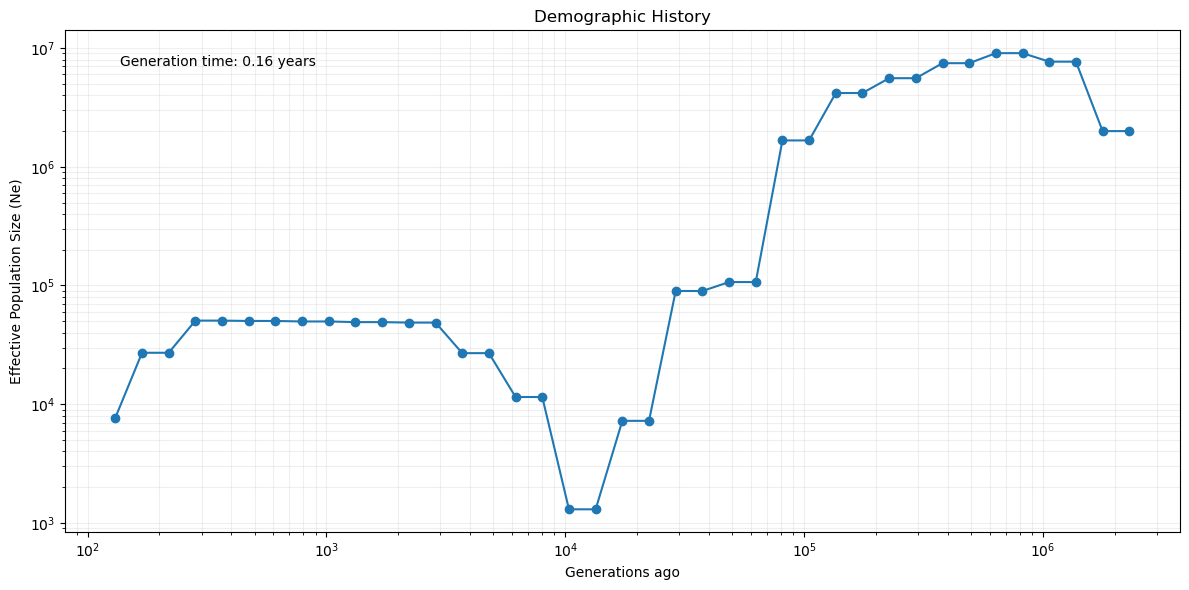

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Your provided demography data
demography_data = {
    'years_ago': [
        20.90991, 27.04340, 34.97601, 45.23550, 58.50439,
        75.66543, 97.86030, 126.56557, 163.69094, 211.70625,
        273.80586, 354.12109, 457.99511, 592.33841, 766.08851,
        990.80457, 1281.43640, 1657.31899, 2143.45890, 2772.19779,
        3585.36410, 4637.05576, 5997.23919, 7756.40403, 10031.58311,
        12974.13845, 16779.83093, 21701.84380, 28067.62632, 36300.67815,
        46948.72375, 60720.15108, 78531.13893, 101566.60798, 131359.05066,
        169890.48403, 219724.30843, 284175.84417, 367532.89150
    ],
    'Ne_log10': [
        3.886466, 4.433363, 4.433363, 4.704220, 4.704220,
        4.701291, 4.701291, 4.696954, 4.696954, 4.691536,
        4.691536, 4.687589, 4.687589, 4.430142, 4.430142,
        4.060712, 4.060712, 3.114804, 3.114804, 3.860018,
        3.860018, 4.953656, 4.953656, 5.028866, 5.028866,
        6.221847, 6.221847, 6.621246, 6.621246, 6.746056,
        6.746056, 6.872533, 6.872533, 6.957109, 6.957109,
        6.885372, 6.885372, 6.300497, 6.300497
    ]
}

# Convert to DataFrame
demography_df = pd.DataFrame(demography_data)

# Convert years_ago to generations (assuming generation time of 0.16 years)
demography_df['generations_ago'] = demography_df['years_ago'] / 0.16

# Convert Ne_log10 to actual Ne values
demography_df['Ne'] = 10 ** demography_df['Ne_log10']

# Sort by generations_ago to ensure correct plotting order
demography_df = demography_df.sort_values('generations_ago')

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(demography_df['generations_ago'], demography_df['Ne'], '-o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Generations ago')
plt.ylabel('Effective Population Size (Ne)')
plt.title('Demographic History')
plt.grid(True, which="both", ls="-", alpha=0.2)

# Add some annotations
plt.text(0.05, 0.95, 'Generation time: 0.16 years', transform=plt.gca().transAxes, 
         verticalalignment='top', fontsize=10)

# Improve the layout
plt.tight_layout()

# Show the plot
plt.show()

Thibaut's code: bottleneck

In [ ]:
sample_size=10
mu=1e-9
for L in [10**7]:#
    for r in [1]:
        r=mu*r
        Ne=10**6#
        demography=msprime.Demography()
        demography.add_population(initial_size=(Ne))
        demography.add_population_parameters_change(time=100, growth_rate=0, initial_size=Ne/10)
        demography.add_population_parameters_change(time=1000, growth_rate=0, initial_size=Ne)
        for x in range(1,11):
            #ts=msprime.DemographyDebugger(demography=demography,model=msprime.BetaCoalescent(alpha=alpha))
            #ts.print_history()
            ts=msprime.sim_ancestry(samples=sample_size,random_seed=((x+3)**2),recombination_rate=r,sequence_length=L,demography=demography,ploidy=1,model=[msprime.StandardCoalescent()])
            mts = msprime.sim_mutations(ts, rate=mu)
            f = open("Table_1_Bottleneck_mu"+str(mu)+'r'+str(r)+'x'+str(x)+'L'+str(L)+".txt","w")
            f.write("segsites: "+str(mts.get_num_sites())+'\n')
            f.write("//"+'\n')
            for tree in ts.trees():
                f.write("["+str(tree.span)+"]"+str(tree.newick())+'\n')
            f.close()

NameError: name 'sample_size' is not defined

In [ ]:
#tree_sequence = tskit.load("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/SINGER_in_out/outputs_beta/trees_trial/BetaCoal_rep0_alpha1.7_m1e-06_ratio0.1_rs152423716_singerout_99.trees")

tree_sequence = tskit.load("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/SINGER_in_out/Consant_pop_size/beta_10reps_50haps/beta/m1e-6/alpha1.7/Beta_rep0_m1e-06_ratio0.1_rs152423716.ts")

NameError: name 'tskit' is not defined

In [46]:
tree_sequence

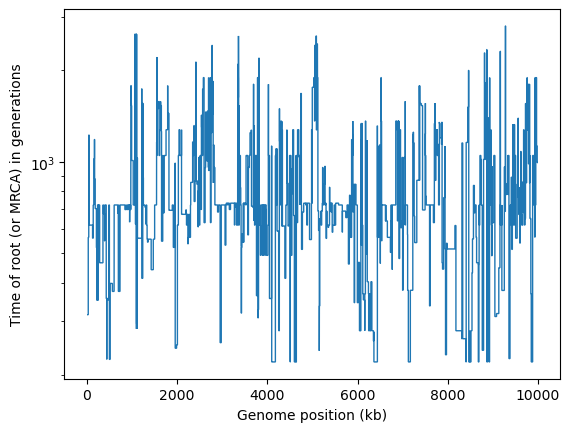

In [19]:
def compute_all_coalescence_times(trees):
    """Compute pairwise coalescence times."""
    mrca_time = []
    for tree in trees.trees():
        mrca = trees.node(tree.root)  # For msprime tree sequences, the root node is the MRCA
        mrca_time.append(mrca.time)  # Collect the time to MRCA
    return np.array(mrca_time)

def process_trees_file(file_path):
    """Process a single .ts file to compute TMRCA."""
    try:
        trees = tskit.load(file_path)  # Load the tree sequence from the .ts file
        return compute_all_coalescence_times(trees)
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

In [ ]:


# Define the directory containing the .trees files
directory = "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/SINGER_in_out/outputs_beta/trees_trial"

# Define the output file path for saving the TMRCA distribution
output_file = os.path.join(directory, "tmrca_distribution.pkl")
def compute_all_coalescence_times(trees):
    """Compute pairwise coalescence times."""
    mrca_time = []
    for tree in trees.trees():
        mrca = trees.node(tree.root)  # For msprime tree sequences, the root node is the MRCA
        mrca_time.append(mrca.time)  # Collect the time to MRCA
    return np.array(mrca_time)

def process_trees_file(file_path):
    """Process a single .ts file to compute TMRCA."""
    try:
        trees = tskit.load(file_path)  # Load the tree sequence from the .ts file
        return compute_all_coalescence_times(trees)
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None
        
# Initialize a list to store the TMRCA values
tmrca_list = []

# Recursively walk through the directory and process all .trees files
for root, dirs, files in os.walk(directory):
    for file in files:
        if file.endswith('.trees'):
            file_path = os.path.join(root, file)
            tmrca_array = process_trees_file(file_path)
            if tmrca_array is not None:
                tmrca_list.append(tmrca_array)

# Combine all TMRCA results into a single numpy array
tmrca_distribution = np.concatenate(tmrca_list) if tmrca_list else np.array([])


    # Save the distribution to a .pkl file
    #with open(output_file, 'wb') as f:
    #    pickle.dump(tmrca_distribution, f)




In [20]:
tmrca_distribution

array([0.02316432, 0.83700995, 0.75272116, ..., 0.38661099, 0.32059681,
       0.13990568])

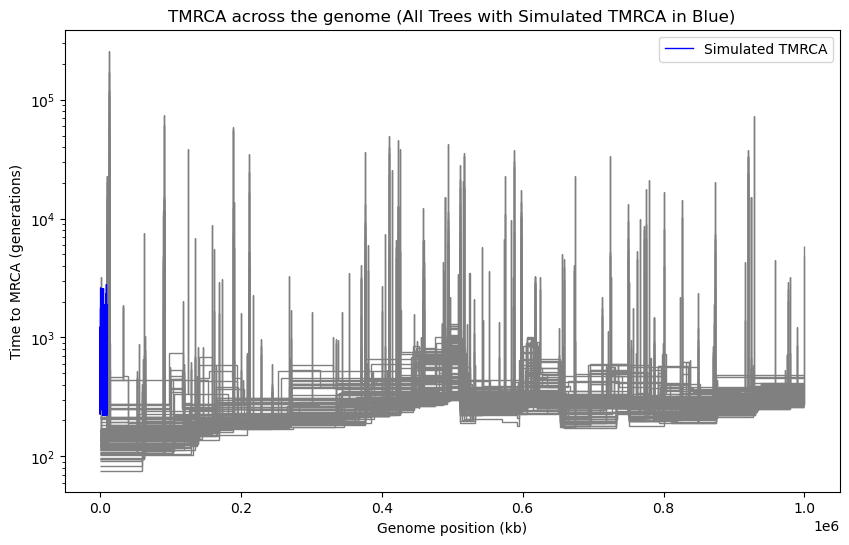

In [ ]:


# Define the directory containing the .trees files
directory = "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/SINGER_in_out/outputs_beta/trees_trial"

# Function to compute coalescence times (TMRCA) for a given tree sequence
def compute_all_coalescence_times(trees):
    """Compute pairwise coalescence times for each tree."""
    kb = [0]  # Starting position (0 kb)
    mrca_time = []
    
    for tree in trees.trees():
        kb.append(tree.interval.right)  # Convert to kilobases (kb)
        mrca = trees.node(tree.root)  # For msprime tree sequences, the root node is the MRCA
        mrca_time.append(mrca.time)  # Collect the time to MRCA
    
    return np.array(mrca_time), kb

# Function to process a single .ts file and compute TMRCA
def process_trees_file(file_path):
    """Process a single .ts file to compute TMRCA."""
    try:
        trees = tskit.load(file_path)  # Load the tree sequence from the .ts file
        return compute_all_coalescence_times(trees)
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None, None

# Initialize a list to store the TMRCA values for each genomic position across all files
all_mrca_times = []
all_kb_positions = []

# Recursively walk through the directory and process all .trees files
for root, dirs, files in os.walk(directory):
    for file in files:
        if file.endswith('.trees'):
            file_path = os.path.join(root, file)
            tmrca_array, kb = process_trees_file(file_path)
            if tmrca_array is not None:
                all_mrca_times.append(tmrca_array)
                all_kb_positions.append(kb)


# Initialize the plot
plt.figure(figsize=(10, 6))

# Loop through all MRCA times and corresponding genomic positions for all trees
for mrca_time, kb in zip(all_mrca_times, all_kb_positions):
    # Plot each tree's MRCA time along the genome
    plt.stairs(mrca_time, kb, baseline=None, color="grey")  # Gray for each tree's TMRCA

# Load the simulated tree sequence from a file
tree_sequence = tskit.load("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/SINGER_in_out/Consant_pop_size/beta_10reps_50haps/beta/m1e-6/alpha1.7/Beta_rep0_m1e-06_ratio0.1_rs152423716.ts")

# Initialize lists to store MRCA times and genomic positions for the specific tree sequence
kb = [0]  # Starting genomic position (in kb)
mrca_time = []

# Loop through the trees in the loaded tree sequence
for tree in tree_sequence.trees():
    kb.append(tree.interval.right / 1000)  # Convert genomic position to kb
    mrca = tree_sequence.node(tree.root)  # For msprime tree sequences, the root node is the MRCA
    mrca_time.append(mrca.time)  # Collect the time to MRCA

# Plot the MRCA times for the specific tree sequence in blue
plt.stairs(mrca_time, kb, baseline=None, color="blue", label="Simulated TMRCA")

# Label the axes
plt.xlabel("Genome position (kb)")
plt.ylabel("Time to MRCA (generations)")

# Set the y-axis to log scale
plt.yscale("log")

# Add a title to the plot
plt.title("TMRCA across the genome (All Trees with Simulated TMRCA in Blue)")

# Add a legend to the plot
plt.legend()

# Display the plot
plt.show()


In [ ]:
def compute_pairwise_coalescence_time(ts, leaf_index1, leaf_index2, s):
    windows = np.arange(0, ts.sequence_length, s)
    windows = np.append(windows, ts.sequence_length)
    
    # Compute pairwise diversity (this gives branch length for pairwise coalescence)
    times = ts.diversity(sample_sets=[leaf_index1, leaf_index2], windows=windows, mode='branch') / 2
    
    return times

def compute_all_pairwise_coalescence_times(ts, s):
    windows = np.arange(0, ts.sequence_length, s)
    n = len(windows)
    pairs = list(itertools.combinations(ts.samples(), 2))  # All unique pairs of samples
    m = len(pairs)
    
    # Initialize the array to store all coalescence times
    all_coalescence_times = np.zeros((n, m))
    
    # Compute coalescence time for each pair
    for index, (leaf_index1, leaf_index2) in enumerate(pairs):
        #print(f"Computing pair: {leaf_index1}, {leaf_index2}")
        all_coalescence_times[:, index] = compute_pairwise_coalescence_time(ts, leaf_index1, leaf_index2, s)
    
    return all_coalescence_times, pairs

1997546.9698294231

SFS from ts file

In [29]:
tree_sequence = ts.load("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/SINGER_in_out/Consant_pop_size/beta_10reps_50haps/beta/m1e-7/alpha1.5/Beta_rep0_m1e-07_ratio1.0_rs152423716.ts")

# Assuming 'ts' is your TreeSequence
dfs = tree_sequence.allele_frequency_spectrum(polarised=True, span_normalise=False)
dfs

array([  0., 885., 327., 211., 148., 116.,  76.,  65.,  60.,  38.,  45.,
        33.,  32.,  30.,  33.,  30.,  23.,  24.,  15.,  22.,  16.,  17.,
        20.,  11.,  16.,  20.,  18.,  13.,  17.,  16.,  12.,  11.,   7.,
        11.,  14.,  14.,  12.,  10.,  13.,   4.,  10.,   7.,  12.,   7.,
         5.,  17.,  10.,   4.,  15.,  11.,   0.])

In [ ]:
np.sum(dfs)

np.sum(dfs/np.sum(dfs))

In [22]:
len(dfs)

51

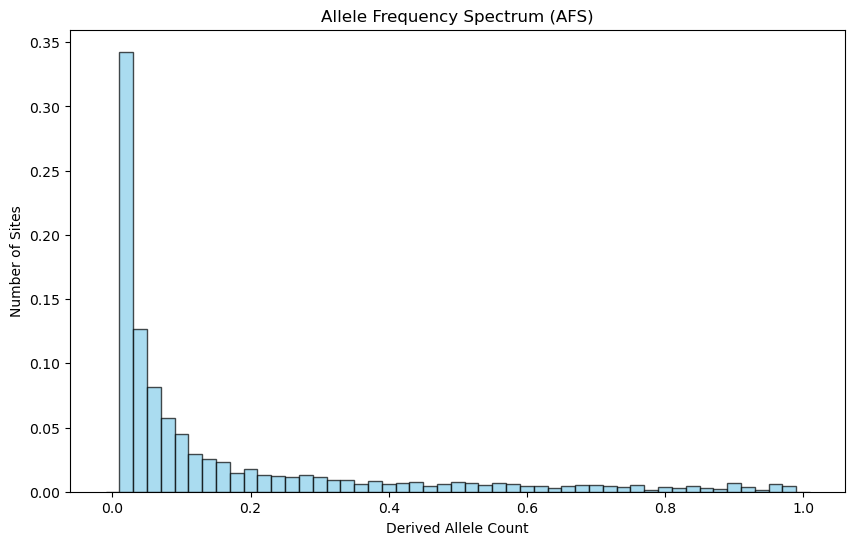

In [30]:

# Plot histogram
plt.figure(figsize=(10, 6))
bar_width = 0.02# Adjust the width of the bars (you can modify this value)

plt.bar(np.arange(len(dfs)) / 50, (dfs/np.sum(dfs)), color='skyblue', edgecolor='black', alpha=0.7, width=bar_width)

# Add labels and title
plt.xlabel("Derived Allele Count")
plt.ylabel("Number of Sites")
plt.title("Allele Frequency Spectrum (AFS)")

# Show plot
plt.show()

#plt.bar(np.arange(len(dfs)) / 50, dfs, color='skyblue', edgecolor='black', alpha=0.7)


In [28]:
# 1. **Normalize SFS**
# Sum all the values in the SFS
total_alleles = np.sum(dfs)

# Normalize the SFS (divide each frequency by the total)
normalized_sfs = dfs / total_alleles

print(len(normalized_sfs))

normalized_sfs

51


array([0.00000000e+00, 3.76079971e-01, 1.88718315e-01, 1.16101392e-01,
       7.82577651e-02, 5.08389861e-02, 3.61299536e-02, 2.68475544e-02,
       2.14209211e-02, 1.67083185e-02, 1.26383434e-02, 1.09960728e-02,
       8.13995002e-03, 8.35415923e-03, 5.21242413e-03, 4.92681185e-03,
       5.28382720e-03, 3.99857194e-03, 3.85576580e-03, 2.57051053e-03,
       2.57051053e-03, 1.64227062e-03, 2.49910746e-03, 1.78507676e-03,
       1.35665834e-03, 1.71367369e-03, 1.49946448e-03, 1.42806141e-03,
       9.28239914e-04, 9.28239914e-04, 7.14030703e-04, 4.99821492e-04,
       8.56836844e-04, 7.14030703e-04, 4.28418422e-04, 5.71224563e-04,
       1.42806141e-04, 2.85612281e-04, 2.14209211e-04, 4.99821492e-04,
       3.57015352e-04, 1.42806141e-04, 7.14030703e-05, 1.42806141e-04,
       7.14030703e-05, 1.42806141e-04, 1.42806141e-04, 4.99821492e-04,
       0.00000000e+00, 7.14030703e-05, 0.00000000e+00])

In [27]:

# For unfolded SFS, we just need to consider the frequencies up to half the sample size (assuming no allele direction)
def logit_transform(sfs, reg=1e-10):
    """Apply logit transformation to unfolded SFS with regularization."""
    return np.array([math.log(i + reg) - math.log(1 - i + reg) for i in sfs])


# Logit-transform the unfolded SFS
logit_sfs = logit_transform(normalized_sfs)
print(logit_sfs)



[-23.02585093  -0.50622039  -1.45835982  -2.02987848  -2.46625755
  -2.92691495  -3.28383422  -3.59036601  -3.82173353  -4.07499909
  -4.35830106  -4.4991601   -4.80279797  -4.77660649  -5.25148417
  -5.30812417  -5.23780674  -5.51781138  -5.5543224   -5.96107689
  -5.96107689  -6.41003179  -5.98931935  -6.32650713  -6.60137306
  -6.36740066  -6.50114659  -6.55000826  -6.98129155  -6.98129155
  -7.24387017  -7.60075939  -7.06140572  -7.24387017  -7.75498147
  -7.46715658  -8.85387899  -8.16058932  -8.4483427   -7.60075939
  -7.93737442  -8.85387899  -9.54709688  -8.85387899  -9.54709688
  -8.85387899  -8.85387899  -7.60075939 -23.02585093  -9.54709688
 -23.02585093]


In [ ]:
sample_size=50

# Remove the first column (msprime pads the sfs with)
logit_sfs_trimmed = logit_sfs[1:(sample_size+1)]

len(logit_sfs_trimmed)

In [20]:
cutoff=15
tail_state = np.sum(logit_sfs_trimmed[cutoff:sample_size])
tail_state

-290.02272043611345

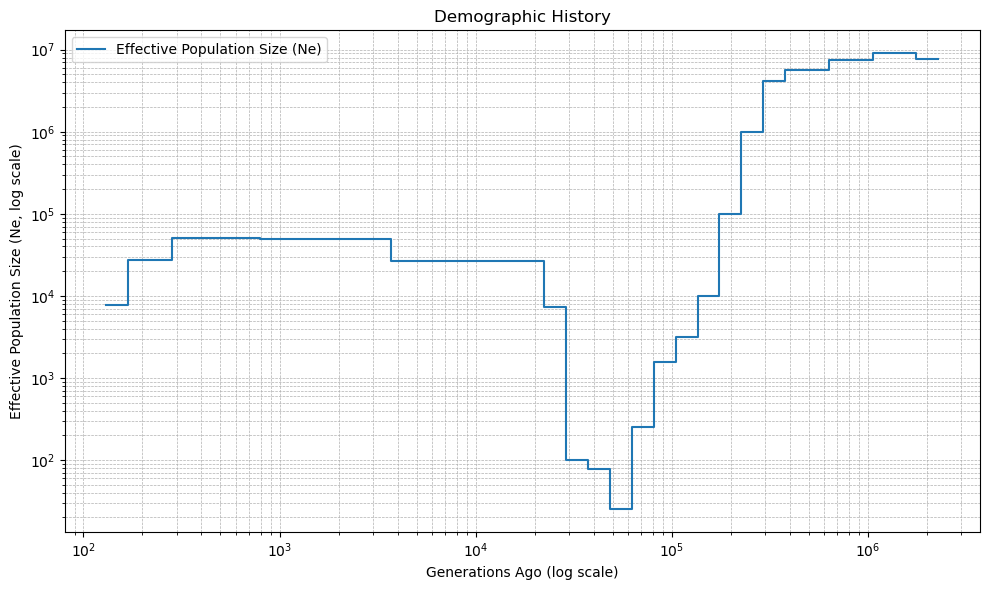

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Input demography data
demography_data = {
    'years_ago': [
        20.90991, 27.04340, 34.97601, 45.23550, 58.50439,
        75.66543, 97.86030, 126.56557, 163.69094, 211.70625,
        273.80586, 354.12109, 457.99511, 592.33841, 766.08851,
        990.80457, 1281.43640, 1657.31899, 2143.45890, 2772.19779,
        3585.36410, 4637.05576, 5997.23919, 7756.40403, 10031.58311,
        12974.13845, 16779.83093, 21701.84380, 28067.62632, 36300.67815,
        46948.72375, 60720.15108, 78531.13893, 101566.60798, 131359.05066,
        169890.48403, 219724.30843, 284175.84417, 367532.89150
    ],
    'Ne_log10': [
        3.886466, 4.433363, 4.433363, 4.704220, 4.704220,
        4.701291, 4.701291, 4.696954, 4.696954, 4.691536,
        4.691536, 4.687589, 4.687589, 4.430142, 4.430142,
        4.430142, 4.430220, 4.430142, 4.430142, 4.430142,
        3.860018, 2.0000, 1.89,1.4,2.4, 3.2, 3.5,
        4, 5, 6, 6.621246, 6.746056,
        6.746056, 6.872533, 6.872533, 6.957109, 6.957109,
        6.885372, 6.885372
    ]
}

# Convert demography data into a DataFrame for easier manipulation
demography_df = pd.DataFrame(demography_data)

# Convert years ago to generations (divide by generation time)
generation_time = 0.16  # Generation time in years
demography_df['generations_ago'] = demography_df['years_ago'] / generation_time

# Convert log10 population sizes to actual Ne values
demography_df['Ne'] = 10 ** demography_df['Ne_log10']

# Plotting the demographic history
plt.figure(figsize=(10, 6))
plt.step(demography_df['generations_ago'], demography_df['Ne'], where='post', label="Effective Population Size (Ne)")

# Log-scale for Ne and generations
plt.xscale('log')
plt.yscale('log')

# Adding labels and title
plt.xlabel('Generations Ago (log scale)')
plt.ylabel('Effective Population Size (Ne, log scale)')
plt.title('Demographic History')
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()


In [27]:
phy_df = pd.DataFrame(demography_data)

# User-defined parameters
num_time_points = len(demography_df)  # Number of time points for demographic changes
generation_time = 0.16  # 1 generation = 0.16 years
sequence_length = 1e6  # Sequence length in base pairs
recombination_rate = 1e-7  # Per base pair per generation
mutation_rate = 1e-8  # Per base pair per generation
sample_size = 89  # Number of samples
output_dir = "./output"  # Output directory
num_replicates = 1  # Number of replicates

alpha=1.2
# Ensure the output directory exists
if not os.path.exists(output_dir):
    os.makedirs(output_dir)


# Function to generate population times in generations
def get_population_time(demography_fromdata):
    divided_years = demography_fromdata['years_ago'] / generation_time  # Convert years to generations
    return divided_years.sort_values()


# Function to sample population sizes
def sample_population_size(demography_fromdata):
    pop_sizes = np.zeros(len(demography_fromdata))
    for i, log10_Ne in enumerate(demography_fromdata['Ne_log10']):
        Ne = 10 ** log10_Ne
        pop_sizes[i] = Ne  # Transform and store population sizes
    return pop_sizes


# Simulation function for Kingman coalescent with bottleneck
def simulate_kingman_replicate():
    # Convert demographic data to appropriate formats
    population_times = get_population_time(demography_df)
    smooth_pop_sizes = sample_population_size(demography_df)

    # Define the demographic model
    demography_model = msprime.Demography()
    demography_model.add_population(initial_size=smooth_pop_sizes[0])  # Initial population size

    # Add population size changes
    for time, size in zip(population_times[1:], smooth_pop_sizes[1:]):
        demography_model.add_population_parameters_change(time=time, initial_size=size)

    # Simulate ancestry and mutations
    tree_sequence = msprime.sim_ancestry(
        samples=sample_size,
        recombination_rate=recombination_rate,
        sequence_length=sequence_length,
        demography=demography_model,
        model=msprime.BetaCoalescent(alpha=alpha), 
        ploidy=1
    )

    tree_sequence = msprime.sim_mutations(tree_sequence, rate=mutation_rate)
    
    return tree_sequence

# Run the simulation
ts_beta= simulate_kingman_replicate()


In [28]:


def calculate_unfolded_normalized_sfs(tree_sequence, sample_size):
    """
    Calculate the unfolded normalized site frequency spectrum (SFS).
    
    Parameters:
    - tree_sequence: The tree sequence from msprime or similar library.
    - sample_size: The number of samples.
    
    Returns:
    - normalized_sfs: The normalized unfolded SFS.
    """
    # Calculate the unfolded SFS
    afs = tree_sequence.allele_frequency_spectrum(polarised=False, span_normalise=False)
    
    # Normalize the SFS (to make it a probability distribution)
    total_alleles = np.sum(afs)
    normalized_sfs = afs / total_alleles
    
    return normalized_sfs


#Assume `tree_sequence` is the tree sequence object and `sample_size` is 89
props = calculate_unfolded_normalized_sfs(ts_beta, 89)
props

array([0. , 0.8, 0.2, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
       0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
       0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
       0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
       0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
       0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
       0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ])

In [29]:
# Assuming `props` is a numpy array
def write_sfs_to_txt(props, filename):
    # Save the normalized SFS to a text file
    np.savetxt(filename, props, fmt='%.8f', delimiter=',', header='Normalized SFS', comments='')

# Call the function to write to a file
write_sfs_to_txt(props, 'normalized_sfs.txt')